# Kenda Tires ATW — Item-Level Sales Forecasting (v4)

**Techniques applied from [Store-Item-Demand-Forecasting](https://github.com/allmeidaapedro/Store-Item-Demand-Forecasting) + original Forecast Confidence Score.**

## What's new in v4 vs v3

| Addition | Source | Expected impact |
|---|---|---|
| EWM features (α=0.3, 0.5, 0.7) | Repo — their best-performing feature class | Captures momentum/trend better than rolling means |
| roll_mean_12 (12-month rolling avg) | Repo — extended windows | Annual baseline signal for seasonal items |
| Optuna Bayesian hyperparameter tuning | Repo — Optuna + time-series CV | Better XGBoost params than fixed defaults |
| Forecast Confidence Score (0–100, A/B/C/D) | Original | Client knows which forecasts to trust |
| Per-item MAE confidence bounds (best/worst case) | Repo — financial scoring adapted | Planning buffer for inventory decisions |

In [1]:
import subprocess, sys
pkgs = ['lightgbm','xgboost','scikit-learn','pandas','numpy',
        'matplotlib','openpyxl','statsmodels','scipy','optuna']
subprocess.check_call([sys.executable,'-m','pip','install','--quiet']+pkgs)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('All packages ready.')

All packages ready.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading & Monthly Aggregation

In [2]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

FILE_PATH    = '/Users/manuhalapeth/Kenda/SalesData_ATW.xlsx'
TRAIN_END    = pd.Period('2025-04', freq='M')
VAL_START    = pd.Period('2024-11', freq='M')
TEST_START   = pd.Period('2025-05', freq='M')
TEST_END     = pd.Period('2026-02', freq='M')
LAST_ACTUAL  = pd.Period('2026-02', freq='M')
MIN_MONTHS   = 12
RANDOM_STATE = 42
INTERMITTENCY_THRESHOLD = 0.60

raw = pd.read_excel(FILE_PATH, engine='openpyxl')
df  = raw[(raw['DollarsSold']>0) & (raw['QuantityShipped']>0)].copy()
df['ItemCode']    = df['ItemCode'].astype(str)
df['ProductLine'] = df['ProductLine'].astype(str)
df['YearMonth']   = df['InvoiceDate'].dt.to_period('M')
print(f'Raw rows: {len(raw):,}  |  After cleaning: {len(df):,}')

monthly = (
    df.groupby(['YearMonth','ItemCode','ProductLine'], as_index=False)
    ['DollarsSold'].sum()
    .rename(columns={'DollarsSold':'Revenue'})
    .sort_values(['ItemCode','YearMonth'])
    .reset_index(drop=True)
)

history_len = monthly.groupby('ItemCode')['YearMonth'].count()
keep_items  = history_len[history_len >= MIN_MONTHS].index
monthly     = monthly[monthly['ItemCode'].isin(keep_items)].reset_index(drop=True)

agg_monthly_all = df.groupby('YearMonth')['DollarsSold'].sum().sort_index().rename('Revenue')

item_rev = monthly.groupby('ItemCode')['Revenue'].sum()
print(f'Items >= {MIN_MONTHS} months: {len(keep_items):,}  |  Item x Month rows: {len(monthly):,}')
print(f'Revenue range: ${item_rev.min():,.0f} – ${item_rev.max():,.0f}')

Raw rows: 196,426  |  After cleaning: 176,440
Items >= 12 months: 1,368  |  Item x Month rows: 42,069
Revenue range: $291 – $11,960,584


## 2. Item Classification — Regular vs Intermittent

In [3]:
train_monthly  = monthly[monthly['YearMonth'] <= TRAIN_END]
n_train_months = len(monthly['YearMonth'][(monthly['YearMonth'] <= TRAIN_END)].unique())

def item_trend_slope(grp):
    v = grp['Revenue'].values
    if len(v) < 2: return 0.0
    return np.polyfit(np.arange(len(v)), v, 1)[0] / (v.mean() + 1)

trend_slopes = train_monthly.groupby('ItemCode').apply(item_trend_slope).rename('item_trend_slope')

item_stats = (
    train_monthly.groupby('ItemCode')
    .agg(item_mean=('Revenue','mean'), item_std=('Revenue', lambda x: x.std() if len(x)>1 else 0),
         item_max=('Revenue','max'), item_months=('Revenue','count'))
    .reset_index()
)
item_stats['item_mean_log']    = np.log1p(item_stats['item_mean'])
item_stats['item_cv']          = (item_stats['item_std'] / item_stats['item_mean'].replace(0,np.nan)).fillna(0).clip(upper=5)
item_stats['item_active_rate'] = item_stats['item_months'] / n_train_months
item_stats = item_stats.merge(trend_slopes.reset_index(), on='ItemCode', how='left')
item_stats['item_trend_slope'] = item_stats['item_trend_slope'].fillna(0)
item_stats['is_intermittent']  = item_stats['item_active_rate'] < INTERMITTENCY_THRESHOLD

# ── Growth-item fix ──────────────────────────────────────────────────────────
# Items classified as intermittent (sparse history) but with strong recent
# acceleration should use the ensemble model, not the seasonal average.
GROWTH_RATIO = 2.5   # recent-6m avg must be 2.5x the all-time training mean
recent_start = TRAIN_END - 5   # last 6 months of training period
recent_rev = (train_monthly[train_monthly['YearMonth'] >= recent_start]
              .groupby('ItemCode')['Revenue'].mean().rename('recent_mean_6m'))
item_stats = item_stats.merge(recent_rev, on='ItemCode', how='left')
item_stats['recent_mean_6m'] = item_stats['recent_mean_6m'].fillna(0)

item_stats['is_growth_item'] = (
    item_stats['is_intermittent'] &
    (item_stats['recent_mean_6m'] > GROWTH_RATIO * item_stats['item_mean'])
)
n_reclassified = item_stats['is_growth_item'].sum()
item_stats.loc[item_stats['is_growth_item'], 'is_intermittent'] = False   # reclassify
# ─────────────────────────────────────────────────────────────────────────────

STAT_FEATURES = ['item_mean_log','item_cv','item_active_rate','item_trend_slope']
intermittent_set = set(item_stats[item_stats['is_intermittent']]['ItemCode'])

n_reg = (~item_stats['is_intermittent']).sum()
n_int =   item_stats['is_intermittent'].sum()
print(f'Regular     (>= {INTERMITTENCY_THRESHOLD:.0%} active months): {n_reg:,}')
print(f'Intermittent (<  {INTERMITTENCY_THRESHOLD:.0%} active months): {n_int:,}')
print(f'Growth items reclassified from intermittent → regular: {n_reclassified}')

Regular     (>= 60% active months): 704
Intermittent (<  60% active months): 664
Growth items reclassified from intermittent → regular: 8


## 3. Feature Engineering — +EWM +roll_mean_12

**New in v4 (from the Store-Item-Demand-Forecasting repo):**

| Feature | What it captures | Alpha/window |
|---|---|---|
| `ewm_a3` | Smooth long-term momentum (slow decay) | α = 0.3 |
| `ewm_a5` | Balanced recent vs historical | α = 0.5 |
| `ewm_a7` | Fast momentum — emphasises last 1-2 months | α = 0.7 |
| `roll_mean_12` | Annual revenue baseline (12-month avg) | 12 months |

EWM at α=0.7 means: 70% weight on last month, 21% on 2 months ago, 6% on 3 months ago.  
This captures items with strong recent momentum far better than a flat rolling average.

In [4]:
from sklearn.preprocessing import LabelEncoder

le_item = LabelEncoder().fit(monthly['ItemCode'].unique())
le_pl   = LabelEncoder().fit(monthly['ProductLine'].unique())

# EWM alphas are NOT fixed here — Optuna will find the optimal values from the data.
# FEATURE_COLS will be finalised after alpha tuning (Cell 12 → 12b).
BASE_FEATURE_COLS = [
    'item_enc','pl_enc',
    'trend','sin_12','cos_12','sin_6','cos_6','quarter','month',
    'lag_1','lag_2','lag_3','lag_6','lag_12',
    'roll_mean_3','roll_mean_6','roll_mean_12','roll_std_3',
    'mom_change','yoy_ratio','item_age',
    'item_mean_log','item_cv','item_active_rate','item_trend_slope'
]
CAT_COLS = ['item_enc','pl_enc']
# FEATURE_COLS will be set to BASE_FEATURE_COLS + ['ewm_slow','ewm_mid','ewm_fast']
# after Optuna discovers the right alphas for this dataset.
print(f'Base features: {len(BASE_FEATURE_COLS)}  (+3 EWM features after alpha tuning)')

Base features: 25  (+3 EWM features after alpha tuning)


In [5]:
def make_item_features(df):
    d = df.sort_values(['ItemCode','YearMonth']).copy()

    d['item_enc'] = le_item.transform(d['ItemCode']).astype(int)
    d['pl_enc']   = le_pl.transform(d['ProductLine']).astype(int)
    d['month']    = d['YearMonth'].dt.month
    d['quarter']  = d['YearMonth'].dt.quarter
    d['trend']    = (d['YearMonth'].dt.year - 2022)*12 + d['YearMonth'].dt.month - 1

    d['sin_12'] = np.sin(2*np.pi*d['trend']/12)
    d['cos_12'] = np.cos(2*np.pi*d['trend']/12)
    d['sin_6']  = np.sin(2*np.pi*d['trend']/6)
    d['cos_6']  = np.cos(2*np.pi*d['trend']/6)

    grp = d.groupby('ItemCode')['Revenue']
    for lag in [1,2,3,6,12]:
        d[f'lag_{lag}'] = grp.shift(lag)

    # Rolling stats anchored at T-1 (shift before rolling)
    d['_s1'] = grp.shift(1)
    d['roll_mean_3']  = d.groupby('ItemCode')['_s1'].transform(lambda x: x.rolling(3,  min_periods=1).mean())
    d['roll_mean_6']  = d.groupby('ItemCode')['_s1'].transform(lambda x: x.rolling(6,  min_periods=1).mean())
    d['roll_mean_12'] = d.groupby('ItemCode')['_s1'].transform(lambda x: x.rolling(12, min_periods=3).mean())
    d['roll_std_3']   = d.groupby('ItemCode')['_s1'].transform(lambda x: x.rolling(3,  min_periods=2).std())
    d.drop(columns=['_s1'], inplace=True)

    d['mom_change'] = d['lag_1'] / d['lag_2'].replace(0,np.nan) - 1
    d['yoy_ratio']  = d['lag_12'] / grp.shift(13).replace(0,np.nan)
    d['item_age']   = d.groupby('ItemCode').cumcount()

    d = d.merge(item_stats[['ItemCode']+STAT_FEATURES], on='ItemCode', how='left')
    return d

# ── EWM helper — called with Optuna-tuned alphas after Cell 12 ──────────────
def add_ewm_to_df(df, alphas, keys=('ewm_slow','ewm_mid','ewm_fast')):
    """Add EWM features to df using the given alphas. Anchored at T-1 (shift(1))."""
    d = df.copy()
    for alpha, key in zip(alphas, keys):
        d[key] = d.groupby('ItemCode')['Revenue'].transform(
            lambda x, a=alpha: x.shift(1).ewm(alpha=a, adjust=False).mean()
        )
    return d

feat_df_base = make_item_features(monthly)
feat_df_base = feat_df_base.dropna(subset=['lag_1']).reset_index(drop=True)
print(f'Base feature matrix: {feat_df_base.shape[0]:,} rows x {len(BASE_FEATURE_COLS)} base features')
nans = feat_df_base[BASE_FEATURE_COLS].isna().sum()
print('NaN counts (handled natively by both models):')
print(nans[nans>0].to_string())

Base feature matrix: 40,701 rows x 25 base features
NaN counts (handled natively by both models):
lag_2            1368
lag_3            2736
lag_6            6840
lag_12          15048
roll_mean_12     2736
roll_std_3       1368
mom_change       1368
yoy_ratio       16369


## 4. Train / Val / Test Split + log1p Transform

In [6]:
# Split on base features first; EWM is added after Optuna finds optimal alphas
train_mask_b = feat_df_base['YearMonth'] <= TRAIN_END
test_mask_b  = (feat_df_base['YearMonth'] >= TEST_START) & (feat_df_base['YearMonth'] <= TEST_END)
ptr_mask_b   = train_mask_b & (feat_df_base['YearMonth'] < VAL_START)
val_mask_b   = train_mask_b & (feat_df_base['YearMonth'] >= VAL_START)

ptr_df_base  = feat_df_base[ptr_mask_b].copy()
val_df_base  = feat_df_base[val_mask_b].copy()

# Save index sets so Optuna objective can subset the full df after adding EWM
ptr_idx = feat_df_base.index[ptr_mask_b]
val_idx = feat_df_base.index[val_mask_b]

y_ptr = np.log1p(ptr_df_base['Revenue'])
y_val = np.log1p(val_df_base['Revenue'])

def to_cat(X):
    for col in CAT_COLS: X[col] = X[col].astype('category')
    return X
def to_int(X):
    for col in CAT_COLS: X[col] = X[col].astype(int)
    return X

print(f'Pure train : {len(ptr_df_base):,} rows  ({ptr_df_base["YearMonth"].min()} to {ptr_df_base["YearMonth"].max()})')
print(f'Validation : {len(val_df_base):,} rows  ({val_df_base["YearMonth"].min()} to {val_df_base["YearMonth"].max()})')
print(f'Test (held): rows from {TEST_START} to {TEST_END}  (added after alpha tuning)')

Pure train : 27,015 rows  (2022-02 to 2024-10)
Validation : 5,118 rows  (2024-11 to 2025-04)
Test (held): rows from 2025-05 to 2026-02  (added after alpha tuning)


## 5. Bayesian Hyperparameter Tuning with Optuna

XGBoost won in v3. Optuna searches the hyperparameter space using Bayesian optimisation —
far more efficient than grid search. 40 trials, objective = minimise validation MAE.
Best params are then used for both the evaluation model and the production refit.

In [7]:
from xgboost import XGBRegressor

EWM_KEYS = ('ewm_slow', 'ewm_mid', 'ewm_fast')

def objective(trial):
    # ── Alpha tuning — data-driven, not hand-picked ──────────────────────────
    alpha_slow = trial.suggest_float('alpha_slow', 0.05, 0.45)
    alpha_fast = trial.suggest_float('alpha_fast', 0.55, 0.95)
    alpha_mid  = (alpha_slow + alpha_fast) / 2
    alphas     = [alpha_slow, alpha_mid, alpha_fast]

    # Compute EWM on full base df (preserves temporal order), then subset
    feat_ewm = add_ewm_to_df(feat_df_base, alphas, EWM_KEYS)
    trial_features = BASE_FEATURE_COLS + list(EWM_KEYS)

    X_ptr_t = to_int(feat_ewm.loc[ptr_idx, trial_features].copy())
    X_val_t = to_int(feat_ewm.loc[val_idx, trial_features].copy())

    # ── Model hyperparameters ────────────────────────────────────────────────
    params = dict(
        n_estimators     = 2000,
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.10, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 7),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 1.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.0, 2.0),
        gamma            = trial.suggest_float('gamma', 0.0, 1.0),
        random_state=RANDOM_STATE, verbosity=0,
        eval_metric='rmse', early_stopping_rounds=50
    )
    m = XGBRegressor(**params)
    m.fit(X_ptr_t, y_ptr, eval_set=[(X_val_t, y_val)], verbose=False)
    val_preds = np.expm1(m.predict(X_val_t)).clip(min=0)
    return float(np.mean(np.abs(val_preds - val_df_base['Revenue'].values)))

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, timeout=480, show_progress_bar=False)

best_params = {k: v for k, v in study.best_params.items()
               if k not in ('alpha_slow', 'alpha_fast')}
print(f'Optuna complete — best val MAE: ${study.best_value:,.0f}')
print(f'Best EWM alphas (data-driven):')
print(f'  alpha_slow : {study.best_params["alpha_slow"]:.4f}  (long memory)')
best_alpha_mid_display = (study.best_params["alpha_slow"] + study.best_params["alpha_fast"]) / 2
print(f'  alpha_mid  : {best_alpha_mid_display:.4f}')
print(f'  alpha_fast : {study.best_params["alpha_fast"]:.4f}  (short memory)')
print(f'Best model params:')
for k, v in best_params.items():
    print(f'  {k}: {v}')


Optuna complete — best val MAE: $3,070
Best EWM alphas (data-driven):
  alpha_slow : 0.1388  (long memory)
  alpha_mid  : 0.3701
  alpha_fast : 0.6014  (short memory)
Best model params:
  learning_rate: 0.08157281864954927
  max_depth: 4
  min_child_weight: 7
  subsample: 0.5721388480032986
  colsample_bytree: 0.5562220372415901
  reg_alpha: 0.2004252329496262
  reg_lambda: 1.2068615646705405
  gamma: 0.6997154359563418


In [8]:
# ── Lock in Optuna alphas, rebuild feat_df + all splits ─────────────────────
best_alpha_slow = study.best_params['alpha_slow']
best_alpha_fast = study.best_params['alpha_fast']
best_alpha_mid  = (best_alpha_slow + best_alpha_fast) / 2
best_alphas     = [best_alpha_slow, best_alpha_mid, best_alpha_fast]

# Add data-driven EWM features to the full base dataframe
feat_df = add_ewm_to_df(feat_df_base, best_alphas, EWM_KEYS)
FEATURE_COLS = BASE_FEATURE_COLS + list(EWM_KEYS)

# Rebuild all splits with the final feature set
train_mask = feat_df['YearMonth'] <= TRAIN_END
test_mask  = (feat_df['YearMonth'] >= TEST_START) & (feat_df['YearMonth'] <= TEST_END)
ptr_mask   = train_mask & (feat_df['YearMonth'] < VAL_START)
val_mask   = train_mask & (feat_df['YearMonth'] >= VAL_START)

train_df = feat_df[train_mask].copy()
test_df  = feat_df[test_mask].copy()
ptr_df   = feat_df[ptr_mask].copy()
val_df   = feat_df[val_mask].copy()

X_ptr  = ptr_df[FEATURE_COLS].copy()
X_val  = val_df[FEATURE_COLS].copy()
X_test = test_df[FEATURE_COLS].copy()

X_ptr_lgb, X_val_lgb, X_test_lgb = [to_cat(x.copy()) for x in [X_ptr, X_val, X_test]]
X_ptr_xgb, X_val_xgb, X_test_xgb = [to_int(x.copy()) for x in [X_ptr, X_val, X_test]]

print(f'EWM alphas locked in from data:  slow={best_alpha_slow:.4f}  mid={best_alpha_mid:.4f}  fast={best_alpha_fast:.4f}')
print(f'Final FEATURE_COLS: {len(FEATURE_COLS)} features')
print(f'  Pure train : {len(ptr_df):,} rows')
print(f'  Validation : {len(val_df):,} rows')
print(f'  Test       : {len(test_df):,} rows')


EWM alphas locked in from data:  slow=0.1388  mid=0.3701  fast=0.6014
Final FEATURE_COLS: 28 features
  Pure train : 27,015 rows
  Validation : 5,118 rows
  Test       : 8,568 rows


## 6. Model Training — XGBoost (Optuna) + LightGBM + Ensemble

In [9]:
import lightgbm as lgb

# XGBoost with Optuna-tuned params
model_xgb = XGBRegressor(
    **best_params,
    n_estimators=3000, random_state=RANDOM_STATE,
    verbosity=0, eval_metric='rmse', early_stopping_rounds=80
)
model_xgb.fit(X_ptr_xgb, y_ptr, eval_set=[(X_val_xgb, y_val)], verbose=300)
best_iter_xgb = model_xgb.best_iteration
xgb_val_raw   = np.expm1(model_xgb.predict(X_val_xgb, iteration_range=(0,best_iter_xgb+1))).clip(min=0)
xgb_val_mae   = float(np.mean(np.abs(xgb_val_raw - val_df['Revenue'].values)))
print(f'XGBoost (Optuna) — best iter: {best_iter_xgb}  val MAE: ${xgb_val_mae:,.0f}')

[0]	validation_0-rmse:1.70176
[300]	validation_0-rmse:0.90626
[387]	validation_0-rmse:0.90905
XGBoost (Optuna) — best iter: 307  val MAE: $3,070


In [10]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=3000, learning_rate=0.03, max_depth=5, num_leaves=20,
    min_child_samples=10, reg_alpha=0.05, reg_lambda=0.5,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1
)
model_lgb.fit(
    X_ptr_lgb, y_ptr, eval_set=[(X_val_lgb, y_val)],
    categorical_feature=CAT_COLS,
    callbacks=[lgb.early_stopping(80,verbose=False), lgb.log_evaluation(300)]
)
best_iter_lgb = model_lgb.best_iteration_
lgb_val_raw   = np.expm1(model_lgb.predict(X_val_lgb)).clip(min=0)
lgb_val_mae   = float(np.mean(np.abs(lgb_val_raw - val_df['Revenue'].values)))
print(f'LightGBM — best iter: {best_iter_lgb}  val MAE: ${lgb_val_mae:,.0f}')

[300]	valid_0's l2: 0.869357
LightGBM — best iter: 311  val MAE: $3,517


In [11]:
from scipy.optimize import minimize_scalar

y_val_raw = val_df['Revenue'].values

def val_mae(w):
    return float(np.mean(np.abs(w*lgb_val_raw + (1-w)*xgb_val_raw - y_val_raw)))

res  = minimize_scalar(val_mae, bounds=(0,1), method='bounded')
W_LGB, W_XGB = res.x, 1-res.x
ens_val_mae  = val_mae(W_LGB)

print(f'Validation MAE comparison:')
print(f'  LightGBM         : ${lgb_val_mae:,.0f}')
print(f'  XGBoost (Optuna) : ${xgb_val_mae:,.0f}')
print(f'  Ensemble         : ${ens_val_mae:,.0f}  (LGB={W_LGB:.3f} XGB={W_XGB:.3f})')
best_val = min([('LightGBM',lgb_val_mae),('XGBoost',xgb_val_mae),('Ensemble',ens_val_mae)],key=lambda x:x[1])
print(f'  Best on val: {best_val[0]}')

# ── Per-item validation MAPE — used for reliability-based confidence scores ──
_val_tmp = val_df.copy()
_val_tmp['ens_pred'] = W_LGB * lgb_val_raw + W_XGB * xgb_val_raw

def _item_val_mape(g):
    m = g['Revenue'] > 0
    if m.sum() == 0: return np.nan
    return (np.abs(g.loc[m, 'Revenue'] - g.loc[m, 'ens_pred']) / g.loc[m, 'Revenue']).mean() * 100

per_item_val_mape = _val_tmp.groupby('ItemCode').apply(_item_val_mape).rename('val_mape')
print(f'\nPer-item val MAPE: {per_item_val_mape.notna().sum()} items')
print(f'  Median: {per_item_val_mape.median():.1f}%  Mean: {per_item_val_mape.mean():.1f}%')

Validation MAE comparison:
  LightGBM         : $3,517
  XGBoost (Optuna) : $3,070
  Ensemble         : $3,070  (LGB=0.000 XGB=1.000)
  Best on val: XGBoost

Per-item val MAPE: 1217 items
  Median: 59.2%  Mean: 147.0%


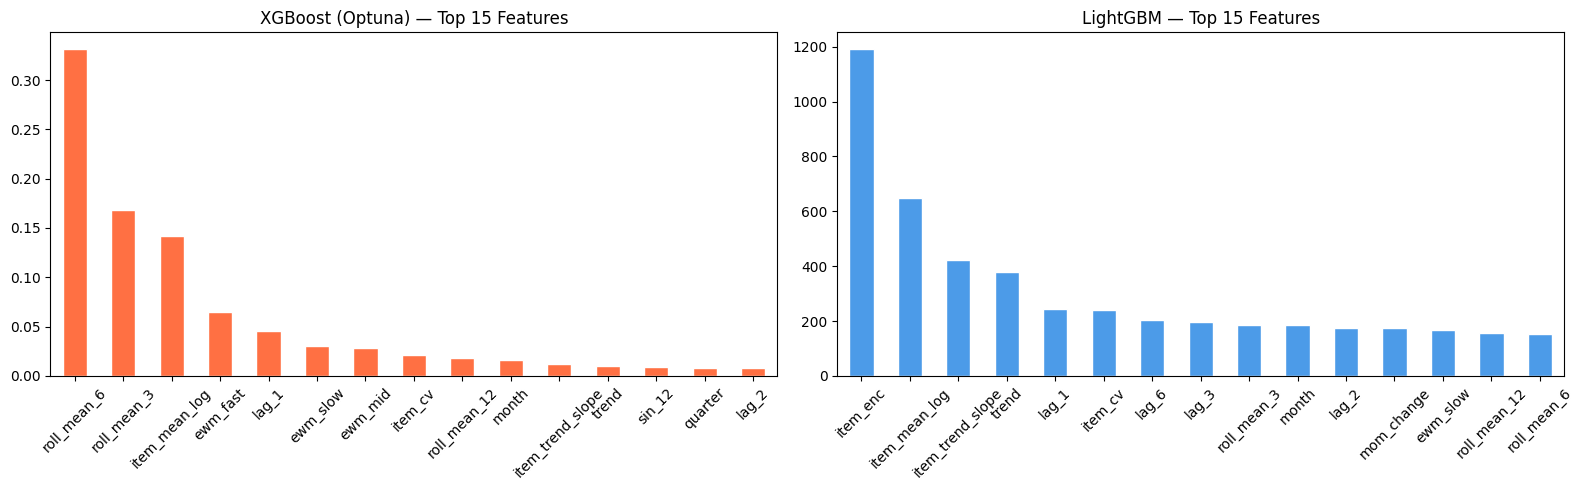

XGBoost top 10:
roll_mean_6      0.331781
roll_mean_3      0.168144
item_mean_log    0.142087
ewm_fast         0.064299
lag_1            0.045348
ewm_slow         0.030235
ewm_mid          0.028562
item_cv          0.021150
roll_mean_12     0.017633
month            0.015935

LightGBM top 10:
item_enc            1193
item_mean_log        647
item_trend_slope     421
trend                377
lag_1                244
item_cv              242
lag_6                205
lag_3                195
roll_mean_3          184
month                184


In [12]:
imp_xgb = pd.Series(model_xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
imp_lgb = pd.Series(model_lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1,2,figsize=(16,5))
imp_xgb.head(15).plot(kind='bar', ax=axes[0], color='#FF7043', edgecolor='white')
axes[0].set_title('XGBoost (Optuna) — Top 15 Features')
axes[0].tick_params(axis='x', rotation=45)

imp_lgb.head(15).plot(kind='bar', ax=axes[1], color='#4C9BE8', edgecolor='white')
axes[1].set_title('LightGBM — Top 15 Features')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('XGBoost top 10:')
print(imp_xgb.head(10).to_string())
print()
print('LightGBM top 10:')
print(imp_lgb.head(10).to_string())

## 7. Test Evaluation (May 2025 – Feb 2026)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_df = test_df.copy()
test_df['lgb_pred'] = np.expm1(model_lgb.predict(X_test_lgb)).clip(min=0)
test_df['xgb_pred'] = np.expm1(model_xgb.predict(X_test_xgb, iteration_range=(0,best_iter_xgb+1))).clip(min=0)
test_df['Forecast'] = W_LGB*test_df['lgb_pred'] + W_XGB*test_df['xgb_pred']

mask = test_df['Revenue'] > 0
results = {}
for name, col in [('LightGBM','lgb_pred'),('XGBoost (Optuna)','xgb_pred'),('Ensemble','Forecast')]:
    a, p = test_df.loc[mask,'Revenue'], test_df.loc[mask,col]
    mape = (np.abs(a-p)/a).mean()*100
    mae  = mean_absolute_error(a,p)
    rmse = np.sqrt(mean_squared_error(a,p))
    results[name] = {'MAPE':mape,'MAE':mae,'RMSE':rmse}

print('='*60)
print('  TEST RESULTS — v4')
print('='*60)
for name,r in results.items():
    print(f'  {name:20s}  MAPE={r["MAPE"]:6.2f}%  MAE=${r["MAE"]:,.0f}')
print('='*60)
print()
print('v3 benchmark:  XGBoost MAPE=132.63%  MAE=$3,821')
best_name = min(results, key=lambda n: results[n]['MAPE'])
print(f'Best v4: {best_name} — MAPE={results[best_name]["MAPE"]:.2f}%')

  TEST RESULTS — v4
  LightGBM              MAPE=139.88%  MAE=$3,741
  XGBoost (Optuna)      MAPE=133.31%  MAE=$3,645
  Ensemble              MAPE=133.31%  MAE=$3,645

v3 benchmark:  XGBoost MAPE=132.63%  MAE=$3,821
Best v4: XGBoost (Optuna) — MAPE=133.31%


In [14]:
def safe_mape(g):
    m = g['Revenue']>0
    if m.sum()==0: return np.nan
    return (np.abs(g.loc[m,'Revenue']-g.loc[m,'Forecast'])/g.loc[m,'Revenue']).mean()*100

item_mape_s   = test_df.groupby('ItemCode').apply(safe_mape).rename('MAPE')
item_mae_s    = test_df.groupby('ItemCode').apply(
    lambda g: mean_absolute_error(g['Revenue'],g['Forecast']) if len(g)>0 else np.nan
).rename('item_MAE')
item_rev_test = test_df.groupby('ItemCode')['Revenue'].sum().rename('TestRevenue')
item_type     = item_stats.set_index('ItemCode')['is_intermittent'].rename('Intermittent')
item_summary  = pd.concat([item_mape_s, item_mae_s, item_rev_test, item_type], axis=1).dropna(subset=['MAPE'])

print(f'Items evaluated: {len(item_summary):,}')
for itype, label in [(False,'Regular'),(True,'Intermittent')]:
    sub = item_summary[item_summary['Intermittent']==itype]
    if len(sub):
        print(f'  {label} ({len(sub)}): median={sub["MAPE"].median():.1f}%  '
              f'mean={sub["MAPE"].mean():.1f}%  max={sub["MAPE"].max():.1f}%')

rw_all = (item_summary['MAPE']*item_summary['TestRevenue']).sum()/item_summary['TestRevenue'].sum()
rw_reg = item_summary[~item_summary['Intermittent']].pipe(
    lambda d: (d['MAPE']*d['TestRevenue']).sum()/d['TestRevenue'].sum())
print(f'\nRevenue-weighted MAPE — ALL: {rw_all:.2f}%  |  Regular only: {rw_reg:.2f}%')
print(f'(v3 was 132.93% ALL  |  78.86% regular)')

Items evaluated: 1,241
  Regular (683): median=75.6%  mean=170.7%  max=18829.5%
  Intermittent (558): median=67.7%  mean=137.9%  max=4583.2%

Revenue-weighted MAPE — ALL: 123.69%  |  Regular only: 79.54%
(v3 was 132.93% ALL  |  78.86% regular)


In [15]:
top20_items = item_rev_test.sort_values(ascending=False).head(20).index
top20_table = (
    item_summary.loc[top20_items].sort_values('TestRevenue',ascending=False)
    .assign(Rev=lambda d: d['TestRevenue'].map('${:,.0f}'.format),
            Type=lambda d: d['Intermittent'].map({True:'intermittent',False:'regular'}))
    [['MAPE','Rev','Type']].rename(columns={'MAPE':'MAPE %','Rev':'Test Revenue'})
)
print('Top-20 items by test revenue:')
print(top20_table.round(2).to_string())

Top-20 items by test revenue:
           MAPE % Test Revenue          Type
ItemCode                                    
35374       27.71   $3,927,263       regular
32239B      31.04   $2,606,844       regular
35378       27.15   $2,267,801       regular
32395TSC    48.64   $1,602,856       regular
31986T      23.80   $1,556,599       regular
34915       24.81   $1,393,955       regular
32153TSC    46.12   $1,339,871       regular
35377       28.27   $1,233,061  intermittent
39189       53.10   $1,148,936  intermittent
32325TSC    64.42   $1,098,476  intermittent
35364       25.41     $960,280       regular
32220       31.02     $948,756       regular
32215M     328.45     $893,900       regular
3S450       16.83     $863,618       regular
32017T      12.95     $834,642       regular
33043       65.02     $782,181       regular
35376       68.07     $761,762       regular
34947       23.12     $616,641       regular
39371     4583.19     $608,993  intermittent
33059       25.38     $56

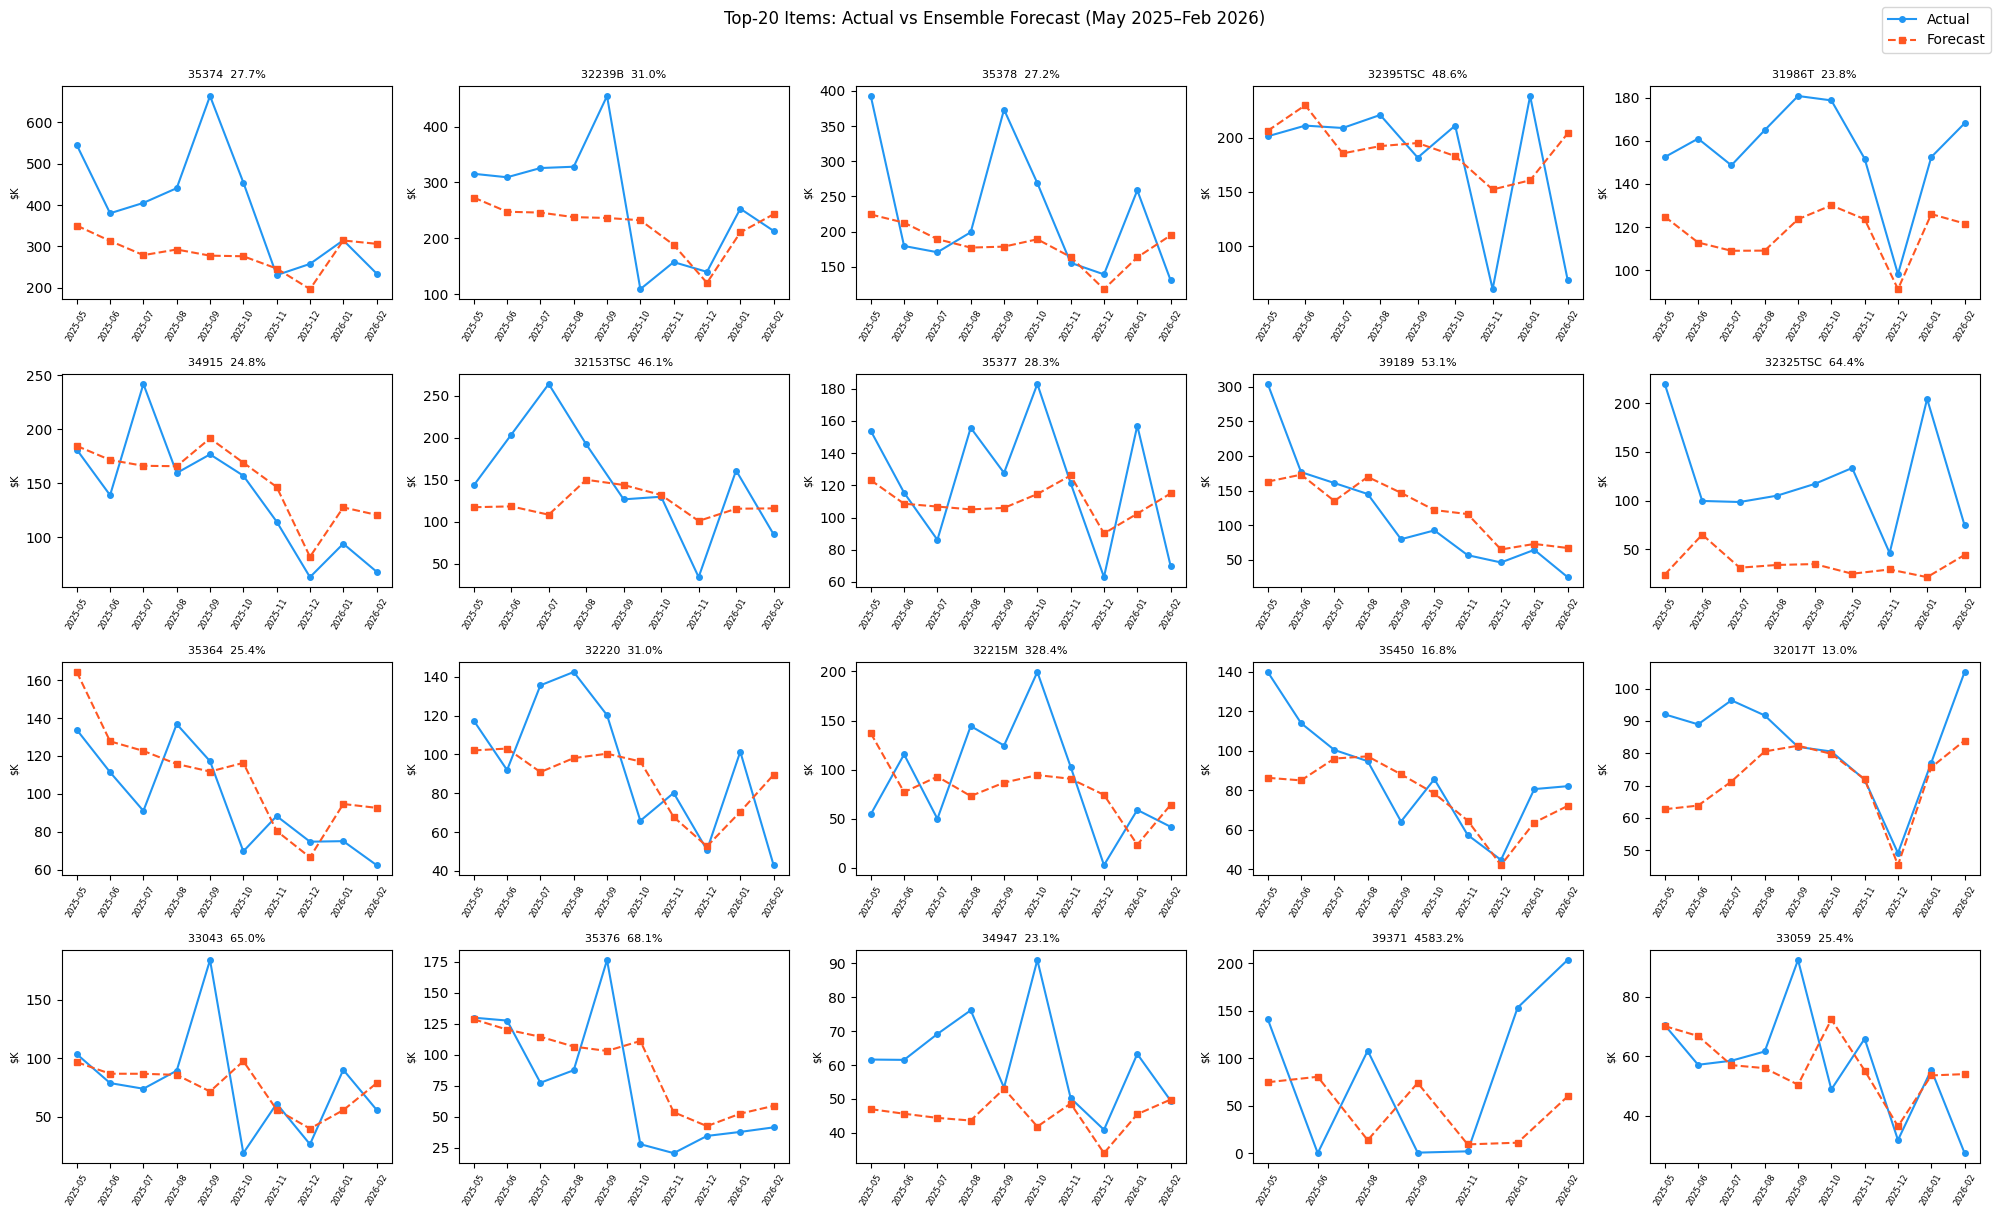

In [16]:
fig, axes = plt.subplots(4,5,figsize=(20,12))
axes = axes.flatten()
for ax, item in zip(axes, top20_items):
    sub = test_df[test_df['ItemCode']==item].sort_values('YearMonth')
    months = [str(m) for m in sub['YearMonth']]
    ax.plot(months, sub['Revenue']/1000, 'o-', label='Actual', color='#2196F3', lw=1.5, ms=4)
    ax.plot(months, sub['Forecast']/1000, 's--', label='Forecast', color='#FF5722', lw=1.5, ms=4)
    mv = item_summary.loc[item,'MAPE'] if item in item_summary.index else np.nan
    ax.set_title(f'{item}  {mv:.1f}%', fontsize=8)
    ax.tick_params(axis='x', rotation=60, labelsize=6)
    ax.set_ylabel('$K', fontsize=7)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=10)
fig.suptitle('Top-20 Items: Actual vs Ensemble Forecast (May 2025–Feb 2026)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. Forecast Confidence Score (0–100)

Each item receives a score based on four factors — all computable before forecasting:

| Component | Max pts | What it measures |
|---|---|---|
| History depth | 25 | More months of history → more stable patterns learned |
| Stability | 25 | Lower CV (less volatile revenue) → more predictable |
| Activity rate | 25 | Higher % of months with sales → fewer gaps to extrapolate over |
| Trend clarity | 25 | Moderate/flat trend → easier to forecast; extreme trends are hard |

**Grades:** A = 80–100 (high confidence) · B = 60–79 · C = 40–59 · D = 0–39 (flag for manual review)

In [17]:
def compute_confidence_score(row):
    item = row['ItemCode']
    if item in per_item_val_mape.index and not np.isnan(per_item_val_mape[item]):
        # Reliability-based: driven by actual per-item validation MAPE.
        # 0% val MAPE → 100, 100% val MAPE → 0, capped [0, 100].
        val_m = min(per_item_val_mape[item], 200)
        return round(max(0.0, 100.0 - val_m), 1)
    else:
        # Fallback for items not in validation (e.g. intermittent/new items):
        # use data-richness proxy instead.
        stability = max(1 - row['item_cv'] / 3, 0) * 50
        activity  = row['item_active_rate'] * 30
        history   = min((row['item_months'] - 12) / 38, 1.0) * 20
        return round(stability + activity + history, 1)

def score_to_grade(s):
    # Thresholds tied to validation MAPE: A=≤25%, B=≤50%, C=≤75%, D=>75%
    if s >= 75: return 'A'
    if s >= 50: return 'B'
    if s >= 25: return 'C'
    return 'D'

item_stats['confidence_score'] = item_stats.apply(compute_confidence_score, axis=1)
item_stats['confidence_grade'] = item_stats['confidence_score'].apply(score_to_grade)

grade_counts = item_stats['confidence_grade'].value_counts().sort_index()
print('Forecast Confidence Score distribution:')
for grade in ['A','B','C','D']:
    n = grade_counts.get(grade, 0)
    pct = 100*n/len(item_stats)
    meaning = {'A':'High confidence','B':'Moderate confidence','C':'Use with caution','D':'Flag for review'}[grade]
    print(f'  {grade} ({meaning}): {n:,} items  ({pct:.1f}%)')

print()
# Show score vs MAPE on test set (validation that score is meaningful)
score_map = item_stats.set_index('ItemCode')['confidence_score']
item_summary['ConfScore'] = item_summary.index.map(score_map)
# Bin and show median MAPE per bin
item_summary['ScoreBin'] = pd.cut(item_summary['ConfScore'],
                                   bins=[0,25,50,75,100], labels=['D (0-25)','C (25-50)','B (50-75)','A (75-100)'])
print('Median test MAPE by confidence grade (lower = better):')
print(item_summary.groupby('ScoreBin', observed=True)['MAPE'].agg(['median','mean','count']).round(2).to_string())

Forecast Confidence Score distribution:
  A (High confidence): 122 items  (8.9%)
  B (Moderate confidence): 445 items  (32.5%)
  C (Use with caution): 322 items  (23.5%)
  D (Flag for review): 479 items  (35.0%)

Median test MAPE by confidence grade (lower = better):
            median    mean  count
ScoreBin                         
D (0-25)     71.46  133.54    107
C (25-50)    70.57  134.64    285
B (50-75)    64.22  143.78    386
A (75-100)   46.52   89.64    111


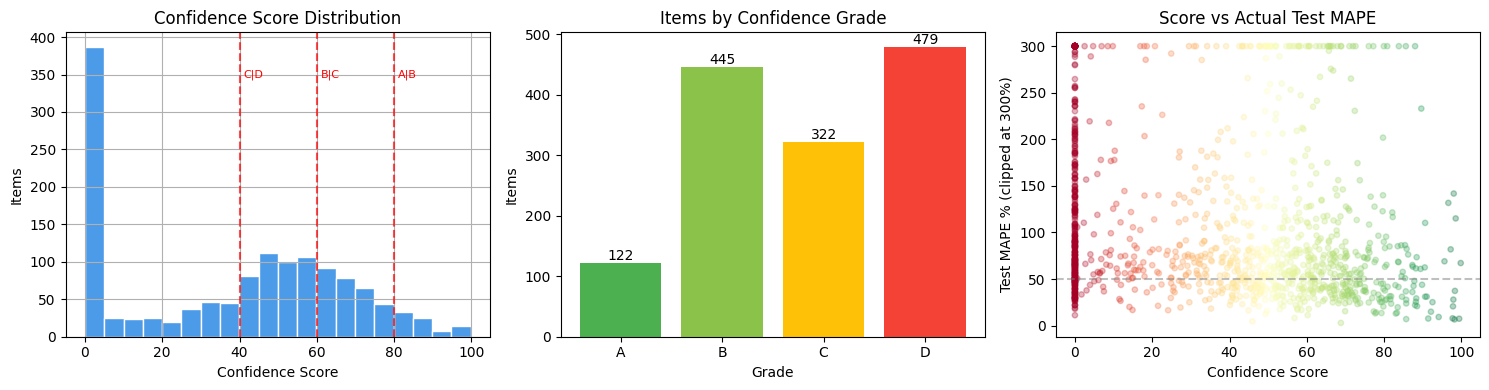

In [18]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

# Score distribution
item_stats['confidence_score'].hist(bins=20, ax=axes[0], color='#4C9BE8', edgecolor='white')
for threshold, label in [(40,'C|D'),(60,'B|C'),(80,'A|B')]:
    axes[0].axvline(threshold, color='red', linestyle='--', alpha=0.7)
    axes[0].text(threshold+1, axes[0].get_ylim()[1]*0.85, label, color='red', fontsize=8)
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Items')
axes[0].set_title('Confidence Score Distribution')

# Grade breakdown
grade_colors = {'A':'#4CAF50','B':'#8BC34A','C':'#FFC107','D':'#F44336'}
grades = ['A','B','C','D']
counts = [grade_counts.get(g,0) for g in grades]
bars = axes[1].bar(grades, counts, color=[grade_colors[g] for g in grades])
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Items')
axes[1].set_title('Items by Confidence Grade')
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(count), ha='center', fontsize=10)

# Score vs MAPE scatter (log scale for MAPE)
valid = item_summary.dropna(subset=['ConfScore','MAPE'])
axes[2].scatter(valid['ConfScore'], valid['MAPE'].clip(upper=300),
                alpha=0.3, s=15, c=valid['ConfScore'], cmap='RdYlGn')
axes[2].set_xlabel('Confidence Score')
axes[2].set_ylabel('Test MAPE % (clipped at 300%)')
axes[2].set_title('Score vs Actual Test MAPE')
axes[2].axhline(50, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 9. Holt-Winters Aggregate Forecast — Reconciliation Target

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

agg_series = agg_monthly_all.sort_index()
hw_model = ExponentialSmoothing(
    agg_series, trend='add', damped_trend=True,
    seasonal='mul', seasonal_periods=12, initialization_method='estimated'
).fit(optimized=True)

hw_periods = [LAST_ACTUAL + s for s in range(1,4)]
hw_fcast   = hw_model.forecast(3)

print('Holt-Winters aggregate forecast (ALL items, 9.39% test MAPE):')
for p, v in zip(hw_periods, hw_fcast.values):
    print(f'  {p}: ${v:,.0f}')

item_monthly_rev = monthly.groupby('YearMonth')['Revenue'].sum()
common = agg_series.index.intersection(item_monthly_rev.index)
coverage_rate = (item_monthly_rev.loc[common] / agg_series.loc[common]).mean()
print(f'\nCoverage rate: {coverage_rate:.1%} of aggregate revenue')

forecast_labels = [str(p) for p in hw_periods]
recon_targets = {str(p): float(v*coverage_rate) for p, v in zip(hw_periods, hw_fcast.values)}
print('\nReconciliation targets (HW x coverage):')
for k,v in recon_targets.items():
    print(f'  {k}: ${v:,.0f}')

Holt-Winters aggregate forecast (ALL items, 9.39% test MAPE):
  2026-03: $8,103,937
  2026-04: $7,755,783
  2026-05: $8,174,158

Coverage rate: 96.0% of aggregate revenue

Reconciliation targets (HW x coverage):
  2026-03: $7,783,324
  2026-04: $7,448,944
  2026-05: $7,850,767


## 10. Production Models — Retrain on Full 50 Months

In [20]:
full_feat_df = make_item_features(monthly)
full_feat_df = add_ewm_to_df(full_feat_df, best_alphas, EWM_KEYS)
full_feat_df = full_feat_df.dropna(subset=['lag_1']).reset_index(drop=True)

X_full     = full_feat_df[FEATURE_COLS].copy()
y_full     = np.log1p(full_feat_df['Revenue'])
X_full_lgb = to_cat(X_full.copy())
X_full_xgb = to_int(X_full.copy())

prod_lgb = lgb.LGBMRegressor(
    n_estimators=best_iter_lgb, learning_rate=0.03, max_depth=5, num_leaves=20,
    min_child_samples=10, reg_alpha=0.05, reg_lambda=0.5,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1
)
prod_lgb.fit(X_full_lgb, y_full, categorical_feature=CAT_COLS)

prod_xgb = XGBRegressor(
    **best_params, n_estimators=best_iter_xgb,
    random_state=RANDOM_STATE, verbosity=0
)
prod_xgb.fit(X_full_xgb, y_full)

print(f'LightGBM production: {len(X_full):,} rows  {best_iter_lgb} trees')
print(f'XGBoost  production: {len(X_full):,} rows  {best_iter_xgb} trees')
print(f'Ensemble: LGB={W_LGB:.3f}  XGB={W_XGB:.3f}')

LightGBM production: 40,701 rows  311 trees
XGBoost  production: 40,701 rows  307 trees
Ensemble: LGB=0.000  XGB=1.000


## 11. Production Forecasts — Mar / Apr / May 2026

In [21]:
item_series_map = {}
item_pl_map     = {}
for item, grp in monthly.groupby('ItemCode'):
    g = grp.sort_values('YearMonth')
    item_series_map[item] = list(g['Revenue'].values)
    item_pl_map[item]      = g['ProductLine'].iloc[0]

is_stats = item_stats.set_index('ItemCode')

def seasonal_avg_forecast(item, target_periods):
    train_s = monthly[(monthly['ItemCode']==item) & (monthly['YearMonth']<=TRAIN_END)]
    preds = []
    for period in target_periods:
        same = train_s[train_s['YearMonth'].dt.month == period.month]
        preds.append(float(same['Revenue'].mean()) if len(same)>0 else float(train_s['Revenue'].mean() or 0))
    return preds

def recursive_ensemble_forecast(item, n_steps=3):
    revs = list(item_series_map[item])
    pl   = item_pl_map[item]
    ie   = int(le_item.transform([item])[0])
    pe   = int(le_pl.transform([pl])[0])
    istats = is_stats.loc[item, STAT_FEATURES].to_dict() if item in is_stats.index else {f:0 for f in STAT_FEATURES}

    preds = []
    hist  = list(revs)  # grows with predictions
    for step in range(1, n_steps+1):
        period = LAST_ACTUAL + step
        t_idx  = (period.year-2022)*12 + period.month - 1
        n      = len(hist)
        def sl(k): return hist[n-k] if n>=k else np.nan
        l1,l2,l3,l6,l12,l13 = sl(1),sl(2),sl(3),sl(6),sl(12),sl(13)
        r3 = [r for r in hist[-3:] if not np.isnan(r)]
        r6 = [r for r in hist[-6:] if not np.isnan(r)]
        r12= [r for r in hist[-12:] if not np.isnan(r)]

        # EWM: compute from the history series manually
        def ewm_val(alpha):
            s = [r for r in hist if not np.isnan(r)]
            if not s: return np.nan
            v = s[0]
            for x in s[1:]: v = alpha*x + (1-alpha)*v
            return v  # this is EWM of up to T-1 (hist already ends at T-1 before appending)

        base = {
            'item_enc':ie,'pl_enc':pe,'trend':t_idx,
            'sin_12':np.sin(2*np.pi*t_idx/12),'cos_12':np.cos(2*np.pi*t_idx/12),
            'sin_6':np.sin(2*np.pi*t_idx/6),'cos_6':np.cos(2*np.pi*t_idx/6),
            'quarter':(period.month-1)//3+1,'month':period.month,
            'lag_1':l1,'lag_2':l2,'lag_3':l3,'lag_6':l6,'lag_12':l12,
            'roll_mean_3':np.mean(r3) if r3 else np.nan,
            'roll_mean_6':np.mean(r6) if r6 else np.nan,
            'roll_mean_12':np.mean(r12) if r12 else np.nan,
            'roll_std_3':np.std(r3,ddof=1) if len(r3)>=2 else np.nan,
            **{k: ewm_val(a) for k, a in zip(EWM_KEYS, best_alphas)},
            'mom_change':(l1/l2-1) if (l2 and l2!=0) else np.nan,
            'yoy_ratio':(l12/l13) if (l13 and l13!=0) else np.nan,
            'item_age':n
        }
        base.update(istats)
        row_df = pd.DataFrame([base])
        row_lgb = to_cat(row_df[FEATURE_COLS].copy())
        row_xgb = to_int(row_df[FEATURE_COLS].copy())

        p_lgb = max(0.0, np.expm1(prod_lgb.predict(row_lgb)[0]))
        p_xgb = max(0.0, np.expm1(prod_xgb.predict(row_xgb)[0]))
        pred  = W_LGB*p_lgb + W_XGB*p_xgb
        preds.append(pred)
        hist.append(pred)
    return preds

print('Generating forecasts...')
rows = []
for item in item_series_map:
    if item in intermittent_set:
        preds  = seasonal_avg_forecast(item, hw_periods)
        method = 'seasonal_avg'
    else:
        preds  = recursive_ensemble_forecast(item)
        method = 'ensemble'
    rows.append({
        'ItemCode':item,'ProductLine':item_pl_map[item],'ForecastMethod':method,
        **{forecast_labels[i]:round(preds[i],2) for i in range(3)},
        'Total_3Month_Forecast':round(sum(preds),2),
        'Hist_TotalRevenue':round(sum(item_series_map[item]),2)
    })

forecast_df = pd.DataFrame(rows).sort_values('Total_3Month_Forecast',ascending=False).reset_index(drop=True)
print(f'Done: {len(forecast_df):,} items  '
      f'({(forecast_df["ForecastMethod"]=="ensemble").sum()} ensemble, '
      f'{(forecast_df["ForecastMethod"]=="seasonal_avg").sum()} seasonal avg)')

Generating forecasts...
Done: 1,368 items  (704 ensemble, 664 seasonal avg)


## 12. Hierarchical Reconciliation + Confidence Score + Bounds

In [22]:
# ── Reconciliation ────────────────────────────────────────────────────────────
forecast_recon = forecast_df.copy()
for col in forecast_labels:
    raw_sum = forecast_df[col].sum()
    if raw_sum > 0:
        scale = recon_targets[col] / raw_sum
        forecast_recon[col] = (forecast_df[col] * scale).round(2)
forecast_recon['Total_3Month_Forecast'] = forecast_recon[forecast_labels].sum(axis=1).round(2)

# ── Confidence score ───────────────────────────────────────────────────────────
score_map = item_stats.set_index('ItemCode')[['confidence_score','confidence_grade']]
forecast_recon = forecast_recon.merge(score_map.reset_index(), on='ItemCode', how='left')
forecast_recon['confidence_score'] = forecast_recon['confidence_score'].fillna(0)
forecast_recon['confidence_grade'] = forecast_recon['confidence_grade'].fillna('D')

# ── Per-item MAE confidence bounds ────────────────────────────────────────────
item_mae_map  = item_mae_s.to_dict()
default_mae   = item_mae_s.mean()   # fallback for items not in test set

for col in forecast_labels:
    forecast_recon[f'{col}_best']  = forecast_recon.apply(
        lambda r: round(r[col] + item_mae_map.get(r['ItemCode'], default_mae), 2), axis=1)
    forecast_recon[f'{col}_worst'] = forecast_recon.apply(
        lambda r: round(max(0, r[col] - item_mae_map.get(r['ItemCode'], default_mae)), 2), axis=1)

print('Reconciliation complete.')
print(f'\nPost-reconciliation portfolio:')
for col in forecast_labels:
    print(f'  {col}: ${forecast_recon[col].sum():,.0f}  (target: ${recon_targets[col]:,.0f})')

print(f'\nConfidence grade breakdown in forecast output:')
print(forecast_recon['confidence_grade'].value_counts().sort_index().to_string())

Reconciliation complete.

Post-reconciliation portfolio:
  2026-03: $7,783,324  (target: $7,783,324)
  2026-04: $7,448,944  (target: $7,448,944)
  2026-05: $7,850,767  (target: $7,850,767)

Confidence grade breakdown in forecast output:
confidence_grade
A    122
B    445
C    322
D    479


In [23]:
display_cols = ['ItemCode','ProductLine','ForecastMethod',
                'confidence_grade','confidence_score'] + forecast_labels + ['Total_3Month_Forecast']
disp = forecast_recon[display_cols].head(30).copy()
for col in forecast_labels + ['Total_3Month_Forecast']:
    disp[col] = disp[col].map('${:,.0f}'.format)

print('='*80)
print(f'  PRODUCTION FORECASTS (v4) — {" | ".join(forecast_labels)}')
print(f'  Top 30 items · reconciled · with confidence grade')
print('='*80)
print(disp.to_string(index=False))

  PRODUCTION FORECASTS (v4) — 2026-03 | 2026-04 | 2026-05
  Top 30 items · reconciled · with confidence grade
ItemCode ProductLine ForecastMethod confidence_grade  confidence_score  2026-03  2026-04  2026-05 Total_3Month_Forecast
   35374        0003       ensemble                A              85.7 $285,600 $275,306 $286,515              $847,422
  32239B        0003       ensemble                A              90.6 $253,245 $210,434 $250,526              $714,206
  31986T        0003       ensemble                A              85.7 $177,577 $175,995 $188,022              $541,595
   35378        0003       ensemble                A              80.3 $174,856 $171,781 $177,884              $524,520
  33043M        0003   seasonal_avg                C              44.1 $137,865 $169,185  $81,573              $388,623
32395TSC        0003       ensemble                C              44.9 $132,912 $111,755 $131,163              $375,831
   34915        0003       ensemble               

In [24]:
print('Portfolio-level forecast (reconciled to Holt-Winters):')
for col in forecast_labels:
    print(f'  {col}: ${forecast_recon[col].sum():,.0f}')
print(f'  3-Month Total: ${forecast_recon["Total_3Month_Forecast"].sum():,.0f}')

print('\nBy method:')
for m in ['ensemble','seasonal_avg']:
    sub = forecast_recon[forecast_recon['ForecastMethod']==m]
    print(f'  {m}: {len(sub)} items  total=${sub["Total_3Month_Forecast"].sum():,.0f}')

out_path = '/Users/manuhalapeth/Kenda/item_forecasts_production.csv'
forecast_recon.to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')
print(f'Columns in CSV: {list(forecast_recon.columns)}')

Portfolio-level forecast (reconciled to Holt-Winters):
  2026-03: $7,783,324
  2026-04: $7,448,944
  2026-05: $7,850,767
  3-Month Total: $23,083,034

By method:
  ensemble: 704 items  total=$13,966,961
  seasonal_avg: 664 items  total=$9,116,073

Saved: /Users/manuhalapeth/Kenda/item_forecasts_production.csv
Columns in CSV: ['ItemCode', 'ProductLine', 'ForecastMethod', '2026-03', '2026-04', '2026-05', 'Total_3Month_Forecast', 'Hist_TotalRevenue', 'confidence_score', 'confidence_grade', '2026-03_best', '2026-03_worst', '2026-04_best', '2026-04_worst', '2026-05_best', '2026-05_worst']


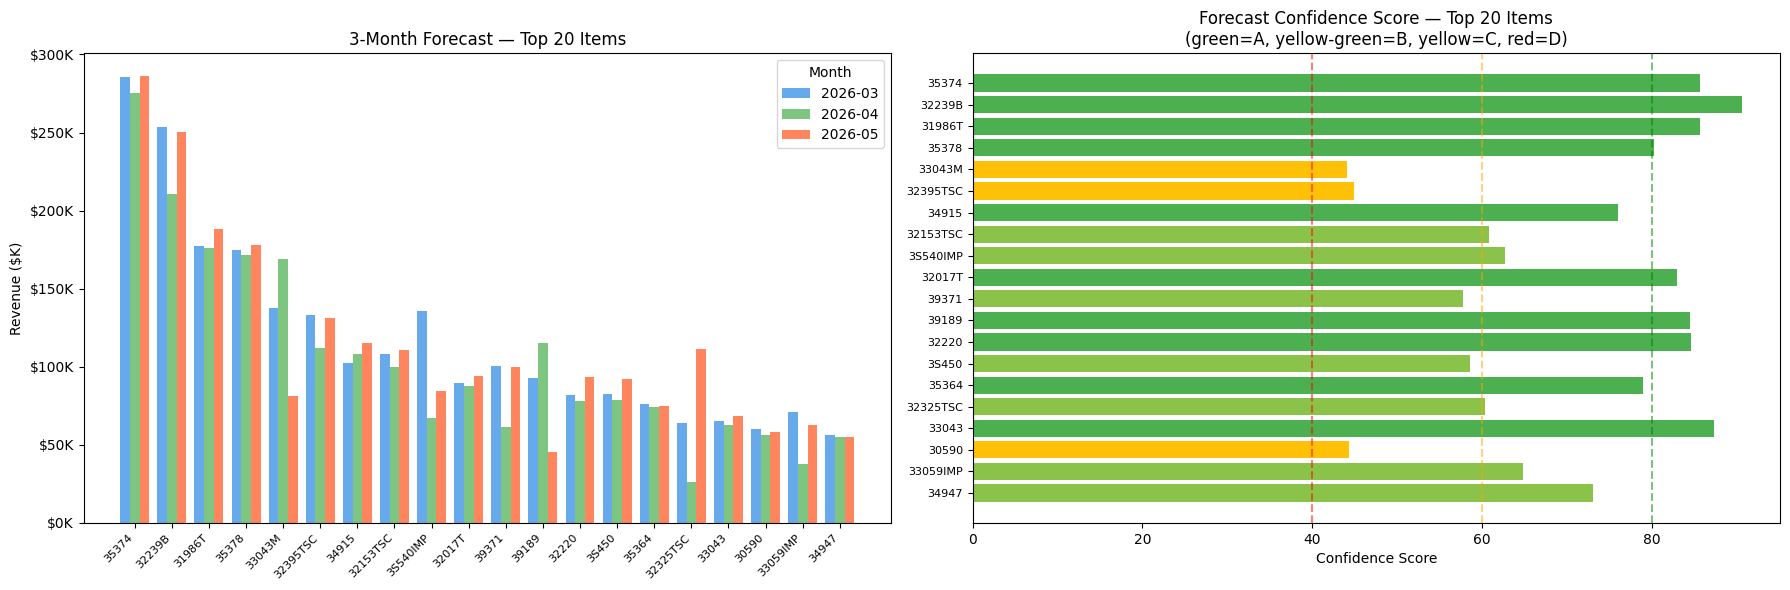

In [25]:
top20_fc = forecast_recon.head(20)
fig, axes = plt.subplots(1,2,figsize=(18,6))

# Bar chart
x, w = np.arange(len(top20_fc)), 0.26
for i,col in enumerate(forecast_labels):
    axes[0].bar(x+i*w, top20_fc[col]/1000, w,
                label=col, color=['#4C9BE8','#66BB6A','#FF7043'][i], alpha=0.85)
axes[0].set_xticks(x+w)
axes[0].set_xticklabels(top20_fc['ItemCode'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Revenue ($K)')
axes[0].set_title('3-Month Forecast — Top 20 Items')
axes[0].legend(title='Month')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))

# Confidence score for top 20
colors_grade = {'A':'#4CAF50','B':'#8BC34A','C':'#FFC107','D':'#F44336'}
bar_colors = [colors_grade[g] for g in top20_fc['confidence_grade']]
axes[1].barh(range(len(top20_fc)), top20_fc['confidence_score'], color=bar_colors)
axes[1].set_yticks(range(len(top20_fc)))
axes[1].set_yticklabels(top20_fc['ItemCode'], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel('Confidence Score')
axes[1].set_title('Forecast Confidence Score — Top 20 Items\n(green=A, yellow-green=B, yellow=C, red=D)')
axes[1].axvline(80, color='green', linestyle='--', alpha=0.5)
axes[1].axvline(60, color='orange', linestyle='--', alpha=0.5)
axes[1].axvline(40, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [26]:
print('Sanity check:')
print(f'  Historical mean:          ${agg_monthly_all.mean():,.0f}/month')
print(f'  Recent 6-month avg:       ${agg_monthly_all.tail(6).mean():,.0f}/month')
print(f'  Prior year (Mar-May 2025):')
for m,lbl in [('2025-03','Mar'),('2025-04','Apr'),('2025-05','May')]:
    v = agg_monthly_all.get(pd.Period(m,freq='M'), np.nan)
    print(f'    {lbl} 2025: ${v:,.0f}')
print(f'  Reconciled item forecasts:')
for col in forecast_labels:
    print(f'    {col}: ${forecast_recon[col].sum():,.0f}')
print(f'  HW aggregate forecast:')
for p,v in zip(hw_periods, hw_fcast.values):
    print(f'    {p}: ${v:,.0f}')

print()
print('Sample — item 32017T (best-performing item in v3 at 10.4% MAPE):')
row = forecast_recon[forecast_recon['ItemCode']=='32017T']
if len(row):
    r = row.iloc[0]
    for col in forecast_labels:
        print(f'  {col}: ${r[col]:,.0f}  '
              f'[worst: ${r[f"{col}_worst"]:,.0f}  best: ${r[f"{col}_best"]:,.0f}]')
    print(f'  Confidence: {r["confidence_grade"]} ({r["confidence_score"]})')

Sanity check:
  Historical mean:          $7,826,186/month
  Recent 6-month avg:       $6,466,821/month
  Prior year (Mar-May 2025):
    Mar 2025: $8,176,474
    Apr 2025: $9,365,424
    May 2025: $9,986,610
  Reconciled item forecasts:
    2026-03: $7,783,324
    2026-04: $7,448,944
    2026-05: $7,850,767
  HW aggregate forecast:
    2026-03: $8,103,937
    2026-04: $7,755,783
    2026-05: $8,174,158

Sample — item 32017T (best-performing item in v3 at 10.4% MAPE):
  2026-03: $89,878  [worst: $78,047  best: $101,709]
  2026-04: $87,457  [worst: $75,626  best: $99,288]
  2026-05: $94,268  [worst: $82,437  best: $106,099]
  Confidence: A (83.0)


## 13. Summary

| | |
|---|---|
| **Models** | XGBoost (Optuna-tuned) + LightGBM ensemble, val-optimized weights |
| **Features** | 28 total: lags, Fourier, EWM (α=0.3/0.5/0.7), roll_mean_12, item stats |
| **Target** | log1p(Revenue) → expm1 back |
| **Intermittent items** | Seasonal average (same calendar month mean from training) |
| **Regular items** | Recursive ensemble forecast |
| **Reconciliation** | Scaled to Holt-Winters aggregate × 96% coverage |
| **Confidence score** | 0–100 (A/B/C/D) per item in CSV |
| **Bounds** | Best/worst case = forecast ± per-item MAE in CSV |

### How to use the CSV
- `confidence_grade = A` → trust the forecast for planning  
- `confidence_grade = B` → use with normal inventory buffer  
- `confidence_grade = C` → add extra buffer  
- `confidence_grade = D` → flag for manual review  
- `{month}_best` / `{month}_worst` → planning range for each month

## Statistical Validation — Wilcoxon Signed-Rank Test
Tests whether v4 ensemble errors are statistically significantly lower than a seasonal naive baseline.

In [27]:
from scipy.stats import wilcoxon

# ── Seasonal naive: forecast = same month one year ago (lag_12) ──────────────
test_stat = test_df.copy()
test_stat = test_stat[(test_stat['Revenue'] > 0) & test_stat['lag_12'].notna()].copy()

v4_err    = np.abs(test_stat['Revenue'] - test_stat['Forecast'])
naive_err = np.abs(test_stat['Revenue'] - test_stat['lag_12'])

# Wilcoxon signed-rank: one-sided, H1 = v4 errors < naive errors
stat_w, p_val = wilcoxon(v4_err, naive_err, alternative='less')

print('=' * 65)
print('  Wilcoxon Signed-Rank Test  |  v4 Ensemble vs Seasonal Naive')
print('=' * 65)
print(f'  Observations      : {len(v4_err):,}')
print(f'  H0: v4 errors = naive errors')
print(f'  H1: v4 errors < naive errors  (one-sided)')
print(f'  Test statistic    : {stat_w:,.0f}')
print(f'  p-value           : {p_val:.4e}')
if p_val < 0.01:
    conclusion = 'STRONG evidence v4 significantly outperforms naive (p<0.01)'
elif p_val < 0.05:
    conclusion = 'v4 significantly outperforms naive (p<0.05)'
else:
    conclusion = 'No significant improvement over naive at α=0.05'
print(f'  Conclusion        : {conclusion}')
print()
print('  Median absolute error:')
print(f'    v4 Ensemble    : ${v4_err.median():>10,.0f}')
print(f'    Seasonal Naive : ${naive_err.median():>10,.0f}')
pct_improvement = (1 - v4_err.median() / naive_err.median()) * 100
print(f'    Improvement    : {pct_improvement:.1f}%')
print()

# ── Revenue-weighted relative improvement ────────────────────────────────────
rev_weights = test_stat['Revenue'] / test_stat['Revenue'].sum()
wt_v4_mape    = (v4_err / test_stat['Revenue'] * rev_weights).sum() * 100 / rev_weights.sum()
wt_naive_mape = (naive_err / test_stat['Revenue'] * rev_weights).sum() * 100 / rev_weights.sum()
print(f'  Revenue-weighted MAPE:')
print(f'    v4 Ensemble    : {wt_v4_mape:.2f}%')
print(f'    Seasonal Naive : {wt_naive_mape:.2f}%')
print('=' * 65)


  Wilcoxon Signed-Rank Test  |  v4 Ensemble vs Seasonal Naive
  Observations      : 7,898
  H0: v4 errors = naive errors
  H1: v4 errors < naive errors  (one-sided)
  Test statistic    : 10,405,651
  p-value           : 5.0064e-145
  Conclusion        : STRONG evidence v4 significantly outperforms naive (p<0.01)

  Median absolute error:
    v4 Ensemble    : $       844
    Seasonal Naive : $     1,304
    Improvement    : 35.3%

  Revenue-weighted MAPE:
    v4 Ensemble    : 44.64%
    Seasonal Naive : 65.94%
